In [3]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression

In [4]:
df = pd.read_csv("Data/AirQualityUCI.csv", sep=';', decimal=',')
df.head()

,Date,Time,CO(GT),PT08.S1(CO),NMHC(GT),C6H6(GT),PT08.S2(NMHC),NOx(GT),PT08.S3(NOx),NO2(GT),PT08.S4(NO2),PT08.S5(O3),T,RH,AH,Unnamed: 15,Unnamed: 16
0,10/03/2004,18.00.00,2.6,1360.0,150.0,11.9,1046.0,166.0,1056.0,113.0,1692.0,1268.0,13.6,48.9,0.7578,NaN,NaN
1,10/03/2004,19.00.00,2.0,1292.0,112.0,9.4,955.0,103.0,1174.0,92.0,1559.0,972.0,13.3,47.7,0.7255,NaN,NaN
2,10/03/2004,20.00.00,2.2,1402.0,88.0,9.0,939.0,131.0,1140.0,114.0,1555.0,1074.0,11.9,54.0,0.7502,NaN,NaN
3,10/03/2004,21.00.00,2.2,1376.0,80.0,9.2,948.0,172.0,1092.0,122.0,1584.0,1203.0,11.0,60.0,0.7867,NaN,NaN
4,10/03/2004,22.00.00,1.6,1272.0,51.0,6.5,836.0,131.0,1205.0,116.0,1490.0,1110.0,11.2,59.6,0.7888,NaN,NaN


In [5]:
# Drop the two empty columns at the end (they're all NaN).
df = df.drop(columns=['Unnamed: 15', 'Unnamed: 16'])

# -200 means "missing" in this dataset. Replace with NaN so we can drop those rows.
df = df.replace(-200, float('nan'))

# Drop any row that has NaN (so the model only sees real numbers).
df = df.dropna()
df.shape

(827, 15)

In [6]:
# Columns we'll use as inputs (all numeric except Date and Time).
feature_cols = ['PT08.S1(CO)', 'NMHC(GT)', 'C6H6(GT)', 'PT08.S2(NMHC)', 'NOx(GT)', 'PT08.S3(NOx)', 'NO2(GT)', 'PT08.S4(NO2)', 'PT08.S5(O3)', 'T', 'RH', 'AH']
# What we want to predict.
target_col = 'CO(GT)'

X = df[feature_cols]
y = df[target_col]

# 80% train, 20% test. random_state so the split is the same every time.
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [7]:
# Create the linear regression model.
model = LinearRegression()
# Train it on the training inputs (X_train) and training target (y_train).
model.fit(X_train, y_train)
# R² on the test set: how much of the variation in CO it explains (0 to 1, higher is better).
print("R² score:", model.score(X_test, y_test))

R² score: 0.9721733275987301


In [8]:
# Coefficient for each feature: positive = higher feature → higher CO, negative = opposite.
pd.DataFrame({'feature': feature_cols, 'coefficient': model.coef_})

,feature,coefficient
0,PT08.S1(CO),0.001456
1,NMHC(GT),0.000934
2,C6H6(GT),0.150894
3,PT08.S2(NMHC),-0.001130
4,NOx(GT),0.004283
5,PT08.S3(NOx),-0.000145
6,NO2(GT),0.004660
7,PT08.S4(NO2),-0.000745
8,PT08.S5(O3),-0.000526
9,T,-0.042919


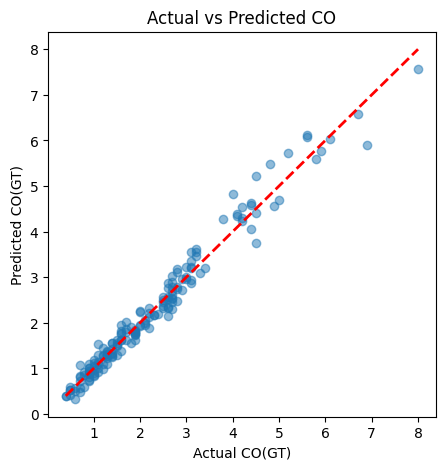

In [10]:
import matplotlib.pyplot as plt

# Predict CO for the test set.
y_pred = model.predict(X_test)

# Scatter: x = real CO, y = predicted CO.
plt.figure(figsize=(5, 5))
plt.scatter(y_test, y_pred, alpha=0.5)
# Diagonal line: perfect predictions would lie here.
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--', lw=2)
plt.xlabel('Actual CO(GT)')
plt.ylabel('Predicted CO(GT)')
plt.title('Actual vs Predicted CO')
plt.show()